In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn import linear_model

必要なライブラリのインポートは以上。

In [2]:
#csvファイルの読み込み
frame ="fish_count.csv"
df = pd.read_csv(frame,encoding='shift-jis')

まずは釣れる魚の数と気温について調べる。

In [3]:
_df = df.loc[1:100,["fish_count","temperature"]]
df_sorted = _df.sort_values(by=["temperature"],ascending=True)
#気温を昇順にする

釣れる魚の数と気温の関係を棒グラフで表す。

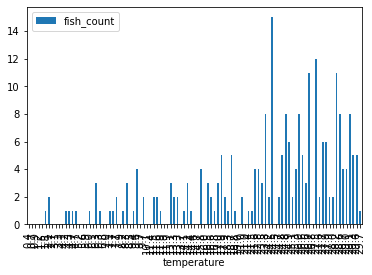

In [4]:
df_sorted.plot(x="temperature",y="fish_count",kind = "bar")

このグラフから気温が高くなればなるほど釣れる魚の数が多いことがわかる。

次に釣れる魚の数と天気の関係を棒グラフで表す。

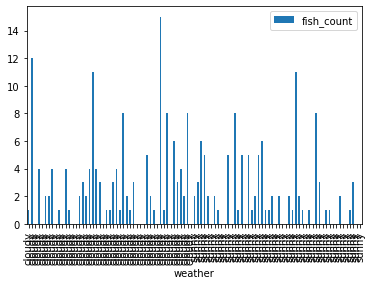

In [5]:
df_weather = df.loc[1:100,["fish_count","weather"]]
df_weather.plot(x="weather",y="fish_count",kind="bar")

このグラフから天気は釣れる魚の数にあまり影響しないことがわかる。

次にuserの中で釣りの上手い人を決める。この時釣った魚の数の上位3人を釣りの上手い人とする。
まず、釣った魚の多い順に並べてあたりをつける。

In [9]:
#ダミー変数
df_dummies = pd.get_dummies(df,columns=['user','weather'])

In [13]:
df_dummies = df_dummies.sort_values(by=["fish_count"],ascending=False)
df_dummies.head(15)

,fish_count,temperature,user_A,user_B,user_C,user_D,user_E,user_F,user_G,user_H,user_I,user_J,weather_cloudy,weather_sunny
40,15,24.5,1,0,0,0,0,0,0,0,0,0,1,0
2,12,27.5,0,0,1,0,0,0,0,0,0,0,1,0
80,11,28.2,1,0,0,0,0,0,0,0,0,0,0,1
20,11,26.7,1,0,0,0,0,0,0,0,0,0,1,0
42,8,24.8,0,0,1,0,0,0,0,0,0,0,1,0
48,8,23.8,0,0,0,0,0,0,0,0,1,0,1,0
29,8,28.6,0,0,0,0,0,0,0,0,0,1,1,0
62,8,26.0,0,0,1,0,0,0,0,0,0,0,0,1
86,8,29.1,0,0,0,0,0,0,1,0,0,0,0,1
0,7,20.6,0,1,0,0,0,0,0,0,0,0,1,0


これより上位3人はA,C,G,Iのうちであるとあたりをつける

In [14]:
df.loc[[1,10,20,30,40,50,60,70,80,90,]]
#55匹

,fish_count,weather,temperature,user
1,1,cloudy,6.0,A
10,1,cloudy,8.2,A
20,11,cloudy,26.7,A
30,2,cloudy,13.3,A
40,15,cloudy,24.5,A
50,2,sunny,11.5,A
60,5,sunny,18.7,A
70,6,sunny,24.9,A
80,11,sunny,28.2,A
90,1,sunny,21.4,A


In [15]:
df.loc[[2,12,22,32,42,52,62,72,82,91,]]
#46匹

,fish_count,weather,temperature,user
2,12,cloudy,27.5,C
12,4,cloudy,9.6,C
22,3,cloudy,6.3,C
32,3,cloudy,8.3,C
42,8,cloudy,24.8,C
52,6,sunny,27.7,C
62,8,sunny,26.0,C
72,1,sunny,4.7,C
82,1,sunny,6.3,C
91,0,sunny,5.6,C


In [16]:
df.loc[[4,16,26,36,46,56,66,76,86,95,]]
#33匹

,fish_count,weather,temperature,user
4,4,cloudy,15.8,G
16,2,cloudy,11.6,G
26,3,cloudy,13.1,G
36,5,cloudy,17.9,G
46,4,cloudy,22.8,G
56,2,sunny,7.7,G
66,5,sunny,26.6,G
76,0,sunny,1.2,G
86,8,sunny,29.1,G
95,0,sunny,7.0,G


In [17]:
df.loc[[8,18,28,38,48,58,68,78,88,97,]]
#22匹

,fish_count,weather,temperature,user
8,4,cloudy,28.7,I
18,2,cloudy,16.6,I
28,1,cloudy,4.3,I
38,1,cloudy,11.9,I
48,8,cloudy,23.8,I
58,0,sunny,5.9,I
68,2,sunny,27.9,I
78,2,sunny,13.3,I
88,0,sunny,9.7,I
97,3,sunny,14.2,I


上位3人はA,C,Gとする

In [18]:
lreg = linear_model.LinearRegression()
#目的変数と説明変数を設定する
fish_except_count = df_dummies.drop("fish_count", axis=1)
X = fish_except_count.values
Y = df_dummies['fish_count'].values
#重回帰分析のモデルを作る
lreg.fit(X,Y)

LinearRegression()

In [19]:
#25度,晴れの日,A,C,Gが釣りに行ったとしてpredict関数に代入する
test1 = np.array([[25,1,0,1,0,0,0,1,0,0,0,0,1]])
lreg.predict(test1)

array([9.43705964])

以上より9匹と予測できる

また釣れる魚への影響を調べると次のようになった

In [21]:
clf = linear_model.LinearRegression()
#目的関数と説明変数を設定する
fish_except_count = df_dummies.drop("fish_count", axis=1)
X = fish_except_count.values
Y = df_dummies['fish_count'].values
clf.fit(X, Y)

LinearRegression()

In [23]:
pd.DataFrame({"Name":fish_except_count.columns,"Coefficients":clf.coef_}).sort_values(by='Coefficients')

,Name,Coefficients
6,user_F,-1.860701
4,user_D,-1.420869
8,user_H,-0.986577
10,user_J,-0.638606
12,weather_sunny,-0.590991
2,user_B,-0.351682
9,user_I,-0.195872
5,user_E,-0.171152
0,temperature,0.203492
11,weather_cloudy,0.590991


参考
・https://deepage.net/features/pandas-get-dummies.html
・https://xtech.nikkei.com/atcl/learning/lecture/19/00108/00006/?P=5
・https://pyhoo.jp/scikit-learn#%E3%80%8C%E7%B3%96%E5%B0%BF%E7%97%85%E6%82%A3%E8%80%85%E3%81%AE%E7%96%BE%E6%82%A3%E9%80%B2%E8%A1%8C%E5%BA%A6%E3%80%8D%E3%81%AE%E8%A8%93%E7%B7%B4%E3%83%87%E3%83%BC%E3%82%BF%E3%83%BB%E6%AD%A3%E8%A7%A3%E3%83%87%E3%83%BC%E3%82%BF%E3%81%AE%E4%BD%9C%E6%88%90
・https://www.youtube.com/watch?v=ZQZ38rK28Gk&list=PLCZyyif9kAwUrhonYORyv8ktC_ehhhAvM